In [24]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [25]:
# =========================
# 2. LOAD DATA
# =========================

file_path = "Consol data from screener.xlsx"

df = pd.read_excel(file_path)

print(df.shape)
df.head()

(2475, 63)


,Name,BSE Code,NSE Code,ISIN Code,Industry Group,Industry,Current Price,Return on capital employed,Profit after tax,Return on assets,...,Interest,Depreciation,EBIT,Net profit,Cash from operations last year,Free cash flow last year,Cash from investing last year,Cash from financing last year,Market Capitalization,Distress label
0,20 Microns,533022.0,20MICRONS,INE144J01027,Minerals & Mining,Industrial Minerals,177.90,19.16,64.82,9.83,...,18.00,20.32,103.84,64.31,31.79,-43.53,-63.26,14.02,626.32,0
1,360 ONE,542772.0,360ONE,INE466L01038,Capital Markets,Stockbroking & Allied,1042.20,12.13,1216.17,5.18,...,1090.24,155.22,2667.12,1216.17,-2921.05,-3016.56,-1613.27,4357.00,42354.28,0
2,3B Blackbio,532067.0,3BBLACKBIO,INE994E01018,Healthcare Services,Healthcare Service Provider,1296.00,25.75,57.43,17.53,...,0.18,1.52,75.04,58.17,43.36,42.46,-33.45,-3.22,1112.90,0
3,3i Infotech,532628.0,3IINFOLTD,INE748C01038,IT - Software,Computers - Software & Consulting,17.65,4.94,58.50,4.06,...,4.23,21.26,52.90,54.74,28.25,29.61,3.19,-25.91,365.86,0
4,3M India,523395.0,3MINDIA,INE470A01017,Diversified,Diversified,33663.85,38.17,327.63,15.20,...,40.85,59.78,945.51,378.35,355.10,300.22,321.96,-788.57,37941.26,0


In [26]:
# =========================
# 3. CLEAN COLUMN NAMES
# =========================

df.columns = df.columns.str.strip()

print(df.columns.tolist())

['Name', 'BSE Code', 'NSE Code', 'ISIN Code', 'Industry Group', 'Industry', 'Current Price', 'Return on capital employed', 'Profit after tax', 'Return on assets', 'Debt to equity', 'Return on equity', 'EPS', 'Debt', 'Earnings yield', 'EVEBITDA', 'Current ratio', 'Interest Coverage Ratio', 'Price to Sales', 'Price to Free Cash Flow', 'Net worth', 'Interest Coverage', 'Debt Capacity', 'Debt To Profit', 'Total Capital Employed', 'Leverage', 'Altman Z Score', 'Market Capt to Cash Flow', 'Market cap to quarterly profit', 'Dividend Payout Ratio', 'Financial leverage', 'Quick ratio', 'Sales', 'OPM', 'Change in promoter holding', 'Sales last year', 'Operating profit last year', 'Other income last year', 'EBIDT last year', 'Depreciation last year', 'EBIT last year', 'Interest last year', 'Profit before tax last year', 'Extraordinary items last year', 'Equity capital', 'Preference capital', 'Reserves', 'Secured loan', 'Unsecured loan', 'Balance sheet total', 'Current assets', 'Current liabilitie

In [27]:
# =========================
# 4. KEEP ONLY REQUIRED COLUMNS
# =========================

required_cols = [
    "Name",
    "Industry",
    "Return on capital employed",
    "Profit after tax",
    "Return on assets",
    "Debt to equity",
    "Debt",
    "Current ratio",
    "Interest Coverage Ratio",
    "Quick ratio",
    "Sales",
    "Balance sheet total",
    "Cash from operations last year",
    "Free cash flow last year",
    "Altman Z Score",
    "Distress label"
]

df_model = df[required_cols].copy()

df_model.head()

,Name,Industry,Return on capital employed,Profit after tax,Return on assets,Debt to equity,Debt,Current ratio,Interest Coverage Ratio,Quick ratio,Sales,Balance sheet total,Cash from operations last year,Free cash flow last year,Altman Z Score,Distress label
0,20 Microns,Industrial Minerals,19.16,64.82,9.83,0.36,163.37,1.78,5.77,1.07,920.21,741.76,31.79,-43.53,4.19,0
1,360 ONE,Stockbroking & Allied,12.13,1216.17,5.18,1.62,15931.31,2.69,2.45,2.69,4361.62,27201.35,-2921.05,-3016.56,3.57,0
2,3B Blackbio,Healthcare Service Provider,25.75,57.43,17.53,0.00,0.27,6.25,416.89,5.37,128.98,340.83,43.36,42.46,8.04,0
3,3i Infotech,Computers - Software & Consulting,4.94,58.50,4.06,0.11,34.79,1.33,12.51,1.33,704.58,570.48,28.25,29.61,3.60,0
4,3M India,Diversified,38.17,327.63,15.20,0.06,103.32,2.28,23.15,1.57,4888.74,2658.09,355.10,300.22,27.23,0


In [28]:
# =========================
# 5. CONVERT NUMERIC COLUMNS
# =========================

numeric_cols = [
    "Return on capital employed",
    "Profit after tax",
    "Return on assets",
    "Debt to equity",
    "Debt",
    "Current ratio",
    "Interest Coverage Ratio",
    "Quick ratio",
    "Sales",
    "Balance sheet total",
    "Cash from operations last year",
    "Free cash flow last year",
    "Altman Z Score",
    "Distress label"
]

for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2475 entries, 0 to 2474
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Name                            2475 non-null   object 
 1   Industry                        2471 non-null   object 
 2   Return on capital employed      2436 non-null   float64
 3   Profit after tax                2475 non-null   float64
 4   Return on assets                2447 non-null   float64
 5   Debt to equity                  2427 non-null   float64
 6   Debt                            2472 non-null   float64
 7   Current ratio                   2471 non-null   float64
 8   Interest Coverage Ratio         2429 non-null   float64
 9   Quick ratio                     2471 non-null   float64
 10  Sales                           2475 non-null   float64
 11  Balance sheet total             2472 non-null   float64
 12  Cash from operations last year  24

In [29]:
# =========================
# 6. CHECK MISSING VALUES
# =========================

df_model.isna().sum()

Name                               0
Industry                           4
Return on capital employed        39
Profit after tax                   0
Return on assets                  28
Debt to equity                    48
Debt                               3
Current ratio                      4
Interest Coverage Ratio           46
Quick ratio                        4
Sales                              0
Balance sheet total                3
Cash from operations last year     7
Free cash flow last year           7
Altman Z Score                     3
Distress label                     0
dtype: int64

In [30]:
# =========================
# 7. HANDLE MISSING VALUES
# =========================

df_model[numeric_cols] = df_model[numeric_cols].fillna(df_model[numeric_cols].median())

df_model.isna().sum()

Name                              0
Industry                          4
Return on capital employed        0
Profit after tax                  0
Return on assets                  0
Debt to equity                    0
Debt                              0
Current ratio                     0
Interest Coverage Ratio           0
Quick ratio                       0
Sales                             0
Balance sheet total               0
Cash from operations last year    0
Free cash flow last year          0
Altman Z Score                    0
Distress label                    0
dtype: int64

In [31]:
# =========================
# 8. CHECK DISTRESS DISTRIBUTION
# =========================

df_model["Distress label"].value_counts()

Distress label
0    1963
1     512
Name: count, dtype: int64

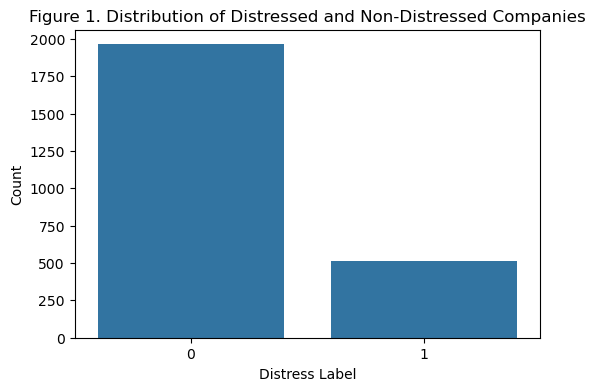

In [32]:
# =========================
# 9. EDA CHART 1: DISTRESS DISTRIBUTION
# =========================

plt.figure(figsize=(6,4))
sns.countplot(x="Distress label", data=df_model)
plt.title("Figure 1. Distribution of Distressed and Non-Distressed Companies")
plt.xlabel("Distress Label")
plt.ylabel("Count")
plt.show()

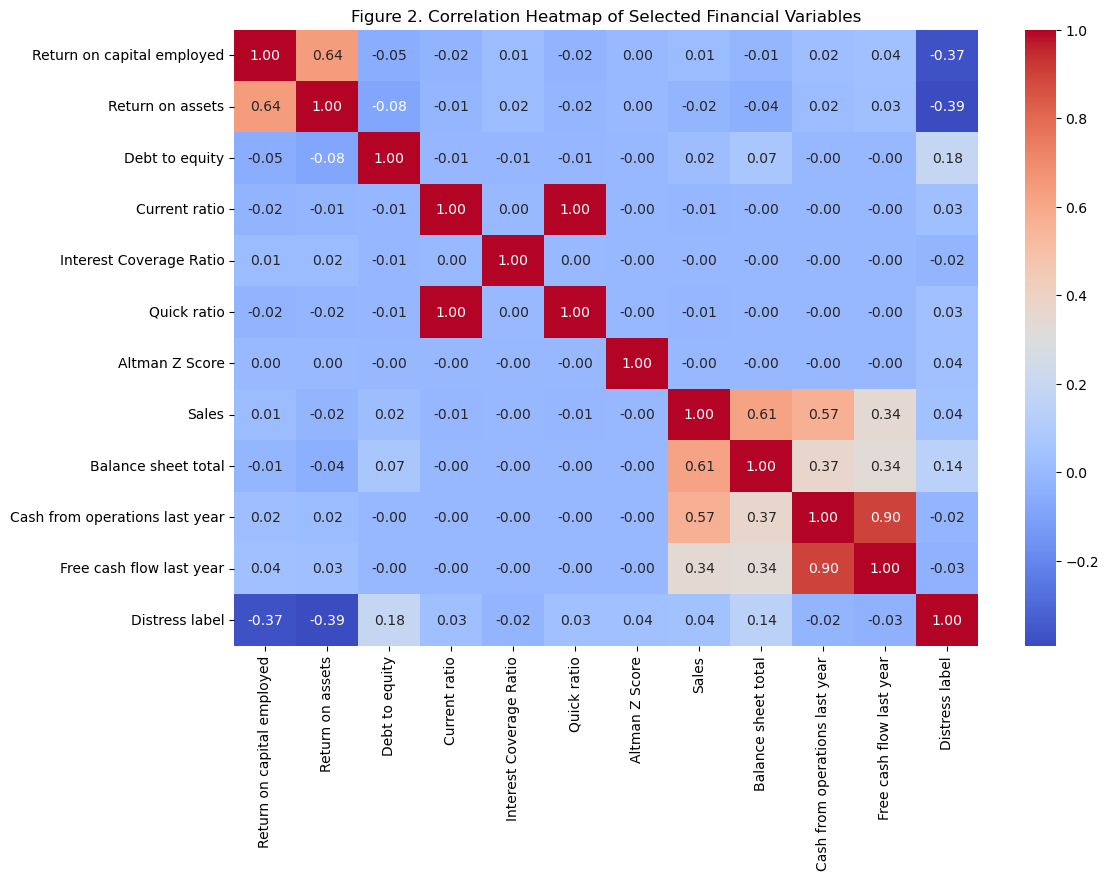

In [33]:
# =========================
# 10. EDA CHART 2: CORRELATION HEATMAP
# =========================

corr_cols = [
    "Return on capital employed",
    "Return on assets",
    "Debt to equity",
    "Current ratio",
    "Interest Coverage Ratio",
    "Quick ratio",
    "Altman Z Score",
    "Sales",
    "Balance sheet total",
    "Cash from operations last year",
    "Free cash flow last year",
    "Distress label"
]

plt.figure(figsize=(12,8))
sns.heatmap(df_model[corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Figure 2. Correlation Heatmap of Selected Financial Variables")
plt.show()

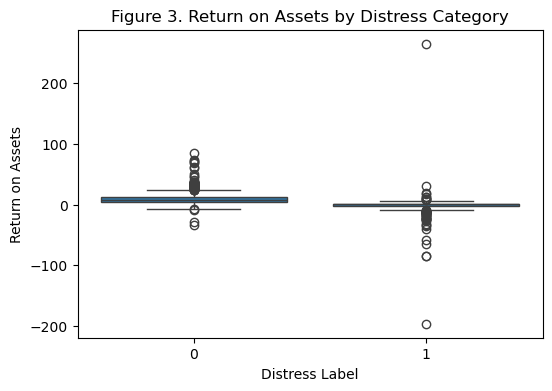

In [34]:
# =========================
# 11. EDA CHART 3: ROA VS DISTRESS
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(x="Distress label", y="Return on assets", data=df_model)
plt.title("Figure 3. Return on Assets by Distress Category")
plt.xlabel("Distress Label")
plt.ylabel("Return on Assets")
plt.show()

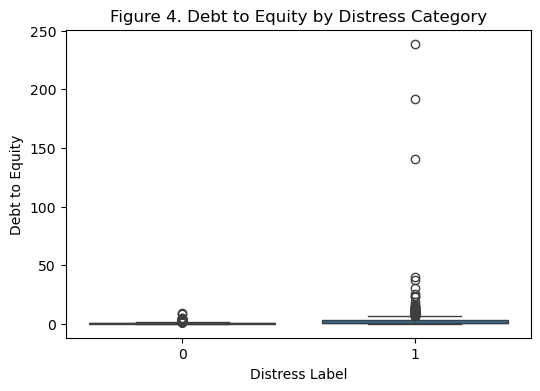

In [35]:
# =========================
# 12. EDA CHART 4: DEBT TO EQUITY VS DISTRESS
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(x="Distress label", y="Debt to equity", data=df_model)
plt.title("Figure 4. Debt to Equity by Distress Category")
plt.xlabel("Distress Label")
plt.ylabel("Debt to Equity")
plt.show()

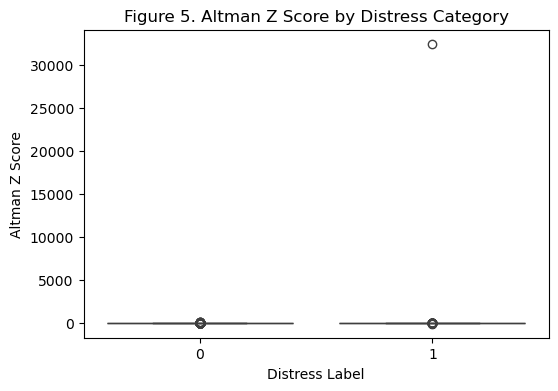

In [36]:
# =========================
# 13. EDA CHART 5: ALTMAN Z SCORE VS DISTRESS
# =========================

plt.figure(figsize=(6,4))
sns.boxplot(x="Distress label", y="Altman Z Score", data=df_model)
plt.title("Figure 5. Altman Z Score by Distress Category")
plt.xlabel("Distress Label")
plt.ylabel("Altman Z Score")
plt.show()

In [37]:
# =========================
# 14. FEATURE ENGINEERING
# =========================

df_model["OCF_to_Sales"] = df_model["Cash from operations last year"] / df_model["Sales"]
df_model["FCF_to_Sales"] = df_model["Free cash flow last year"] / df_model["Sales"]
df_model["Debt_to_Assets"] = df_model["Debt"] / df_model["Balance sheet total"]

df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.fillna(0)

df_model.head()

,Name,Industry,Return on capital employed,Profit after tax,Return on assets,Debt to equity,Debt,Current ratio,Interest Coverage Ratio,Quick ratio,Sales,Balance sheet total,Cash from operations last year,Free cash flow last year,Altman Z Score,Distress label,OCF_to_Sales,FCF_to_Sales,Debt_to_Assets
0,20 Microns,Industrial Minerals,19.16,64.82,9.83,0.36,163.37,1.78,5.77,1.07,920.21,741.76,31.79,-43.53,4.19,0,0.034546,-0.047304,0.220246
1,360 ONE,Stockbroking & Allied,12.13,1216.17,5.18,1.62,15931.31,2.69,2.45,2.69,4361.62,27201.35,-2921.05,-3016.56,3.57,0,-0.669717,-0.691615,0.585681
2,3B Blackbio,Healthcare Service Provider,25.75,57.43,17.53,0.00,0.27,6.25,416.89,5.37,128.98,340.83,43.36,42.46,8.04,0,0.336176,0.329198,0.000792
3,3i Infotech,Computers - Software & Consulting,4.94,58.50,4.06,0.11,34.79,1.33,12.51,1.33,704.58,570.48,28.25,29.61,3.60,0,0.040095,0.042025,0.060984
4,3M India,Diversified,38.17,327.63,15.20,0.06,103.32,2.28,23.15,1.57,4888.74,2658.09,355.10,300.22,27.23,0,0.072636,0.061411,0.038870


In [38]:
# =========================
# 15. PREPARE MODEL DATA
# =========================

feature_cols = [
    "Return on capital employed",
    "Profit after tax",
    "Return on assets",
    "Debt to equity",
    "Debt",
    "Current ratio",
    "Interest Coverage Ratio",
    "Quick ratio",
    "Sales",
    "Balance sheet total",
    "Cash from operations last year",
    "Free cash flow last year",
    "Altman Z Score",
    "OCF_to_Sales",
    "FCF_to_Sales",
    "Debt_to_Assets"
]

X = df_model[feature_cols]
y = df_model["Distress label"]

print(X.shape)
print(y.value_counts())

(2475, 16)
Distress label
0    1963
1     512
Name: count, dtype: int64


In [39]:
# =========================
# 16. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print(y_train.value_counts())
print(y_test.value_counts())

Distress label
0    1374
1     358
Name: count, dtype: int64
Distress label
0    589
1    154
Name: count, dtype: int64


In [40]:
# =========================
# 17. MODEL 1: LOGISTIC REGRESSION
# =========================

lr = LogisticRegression(max_iter=2000, class_weight="balanced")

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("LOGISTIC REGRESSION RESULTS")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

LOGISTIC REGRESSION RESULTS
[[528  61]
 [ 20 134]]
              precision    recall  f1-score   support

           0       0.96      0.90      0.93       589
           1       0.69      0.87      0.77       154

    accuracy                           0.89       743
   macro avg       0.83      0.88      0.85       743
weighted avg       0.91      0.89      0.90       743

ROC-AUC: 0.9447445593455781


C:\Users\Padma T\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
# =========================
# 18. MODEL 2: RANDOM FOREST
# =========================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("RANDOM FOREST RESULTS")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RANDOM FOREST RESULTS
[[582   7]
 [ 14 140]]
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       589
           1       0.95      0.91      0.93       154

    accuracy                           0.97       743
   macro avg       0.96      0.95      0.96       743
weighted avg       0.97      0.97      0.97       743

ROC-AUC: 0.9819637069212621


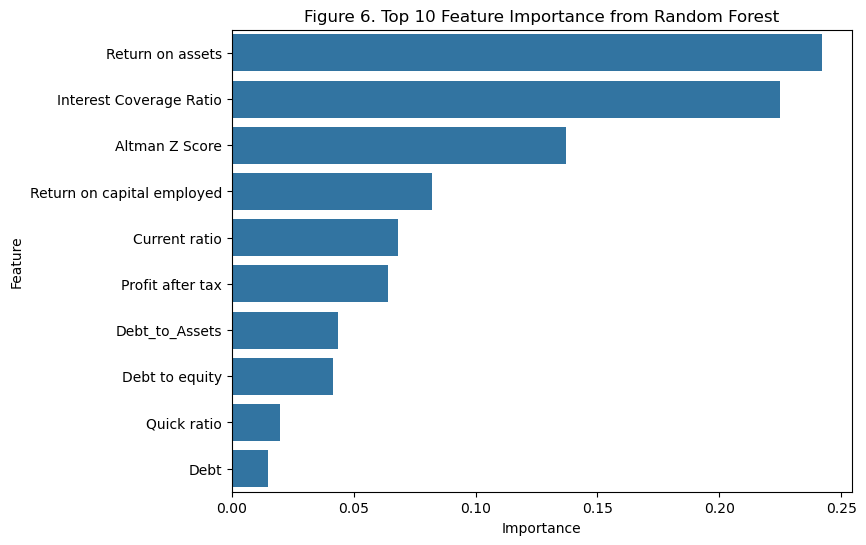

In [42]:
# =========================
# 19. FEATURE IMPORTANCE
# =========================

importance = pd.Series(rf.feature_importances_, index=feature_cols)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importance.values[:10], y=importance.index[:10])
plt.title("Figure 6. Top 10 Feature Importance from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [43]:
# =========================
# 20. SAVE CLEAN DATASET
# =========================

df_model.to_csv("financial_distress_clean_model_data.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
